In [16]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [17]:
# ============================
# B-сплайновый базис (Кокс-де Бор)
# ============================

def make_knot_vector(a, b, n_internal, degree=3):
    """Расширенный вектор узлов (clamped)."""
    internal = np.linspace(a, b, n_internal + 2)
    return np.concatenate([
        np.repeat(a, degree), internal, np.repeat(b, degree)
    ])


def bspline_basis(x, knots, degree=3):
    """Матрица B-сплайнового базиса (N x K)."""
    x = np.asarray(x, dtype=float)
    knots = np.asarray(knots, dtype=float)
    N = len(x)

    B = np.zeros((N, len(knots) - 1))
    for i in range(len(knots) - 1):
        if knots[i] < knots[i + 1]:
            B[(x >= knots[i]) & (x < knots[i + 1]), i] = 1.0
    for i in range(len(knots) - 2, -1, -1):
        if knots[i] < knots[i + 1]:
            B[x == knots[-1], i] = 1.0
            break

    for d in range(1, degree + 1):
        B_new = np.zeros((N, len(knots) - 1 - d))
        for i in range(len(knots) - 1 - d):
            d1 = knots[i + d] - knots[i]
            d2 = knots[i + d + 1] - knots[i + 1]
            if d1 > 0:
                B_new[:, i] += (x - knots[i]) / d1 * B[:, i]
            if d2 > 0:
                B_new[:, i] += (knots[i + d + 1] - x) / d2 * B[:, i + 1]
        B = B_new
    return B


def diff_matrix(K, order=2):
    """Матрица конечных разностей порядка order."""
    D = np.eye(K)
    for _ in range(order):
        D = D[1:, :] - D[:-1, :]
    return D


# ============================
# 2D тензорный P-сплайн
# ============================

def pspline_2d_fit(x, y, Z, n_basis=30, degree=3, penalty_order=2, lam=1.0, x_range=None, y_range=None):
    """
    Подгонка 2D P-сплайна (тензорное произведение).
    Возвращает коэффициенты A и узловые вектора kx, ky.
    """
    if x_range is None:
        x_range = (x[0], x[-1])
    if y_range is None:
        y_range = (y[0], y[-1])

    kx = make_knot_vector(x_range[0], x_range[1], n_basis, degree)
    ky = make_knot_vector(y_range[0], y_range[1], n_basis, degree)
    Bx = bspline_basis(x, kx, degree)
    By = bspline_basis(y, ky, degree)

    Kx, Ky = Bx.shape[1], By.shape[1]

    Dx = diff_matrix(Kx, penalty_order)
    Dy = diff_matrix(Ky, penalty_order)

    BxTBx = Bx.T @ Bx
    ByTBy = By.T @ By
    DxTDx = Dx.T @ Dx
    DyTDy = Dy.T @ Dy

    rhs = (Bx.T @ Z @ By).ravel()

    LHS = (np.kron(ByTBy, BxTBx)
           + lam * np.kron(np.eye(Ky), DxTDx)
           + lam * np.kron(DyTDy, np.eye(Kx)))

    alpha = np.linalg.solve(LHS, rhs)
    A = alpha.reshape(Kx, Ky)

    return A, kx, ky


def pspline_2d_eval(A, kx, ky, x_eval, y_eval, degree=3):
    """Вычисление P-сплайна на сетке."""
    Bx = bspline_basis(x_eval, kx, degree)
    By = bspline_basis(y_eval, ky, degree)
    return Bx @ A @ By.T

In [18]:
# ============================
# Загрузка данных
# ============================

Z_raw = np.load("./data/fuji_elevation.npy").astype(np.float64)
lat = np.load("./data/fuji_lat.npy")
lon = np.load("./data/fuji_lon.npy")

Z_raw = Z_raw[::-1, :]
lat_sn = lat[::-1]

X_coords = lon
Y_coords = lat_sn
x_label = 'Долгота (E)'
y_label = 'Широта (N)'

print(f"Исходная сетка: {Z_raw.shape[0]} x {Z_raw.shape[1]}")
print(f"Высота: {Z_raw.min():.0f} - {Z_raw.max():.0f} м")


# ============================
# Прореживание: каждая 8-я точка
# ============================

step_points = 8
resolution = 500

X_pts = X_coords[::step_points]
Y_pts = Y_coords[::step_points]
Z_pts = Z_raw[::step_points, ::step_points]

print(f"Опорные точки: {Z_pts.shape[0]} x {Z_pts.shape[1]} = {Z_pts.shape[0] * Z_pts.shape[1]}")

X_smooth = np.linspace(X_pts.min(), X_pts.max(), resolution)
Y_smooth = np.linspace(Y_pts.min(), Y_pts.max(), resolution)

Исходная сетка: 1080 x 1080
Высота: 63 - 3759 м
Опорные точки: 135 x 135 = 18225


In [ ]:
# ============================
# Построение P-сплайна по опорным точкам
# ============================

n_basis = 40
lam = 0.010119678286647735

print(f"\nP-сплайн: K={n_basis}, lambda={lam}, степень=3, штраф=2")
print(f"Интерполяция на сетку {resolution} x {resolution}...")

t0 = time.time()
A, kx, ky = pspline_2d_fit(
    X_pts, Y_pts, Z_pts,
    n_basis=n_basis, degree=3, penalty_order=2, lam=lam,
    x_range=(X_coords[0], X_coords[-1]),
    y_range=(Y_coords[0], Y_coords[-1])
)
t_fit = time.time() - t0

Z_smooth = pspline_2d_eval(A, kx, ky, X_smooth, Y_smooth, degree=3)

Kx = len(kx) - 3 - 1
Ky = len(ky) - 3 - 1
print(f"Построение: {t_fit:.2f} с, коэффициентов: {Kx} x {Ky} = {Kx*Ky}")
print(f"Готово! Высота: {np.nanmin(Z_smooth):.0f} - {np.nanmax(Z_smooth):.0f} м")


P-сплайн: K=40, lambda=0.01, степень=3, штраф=2
Интерполяция на сетку 500 x 500...
Построение: 0.52 с, коэффициентов: 44 x 44 = 1936
Готово! Высота: 63 - 3722 м


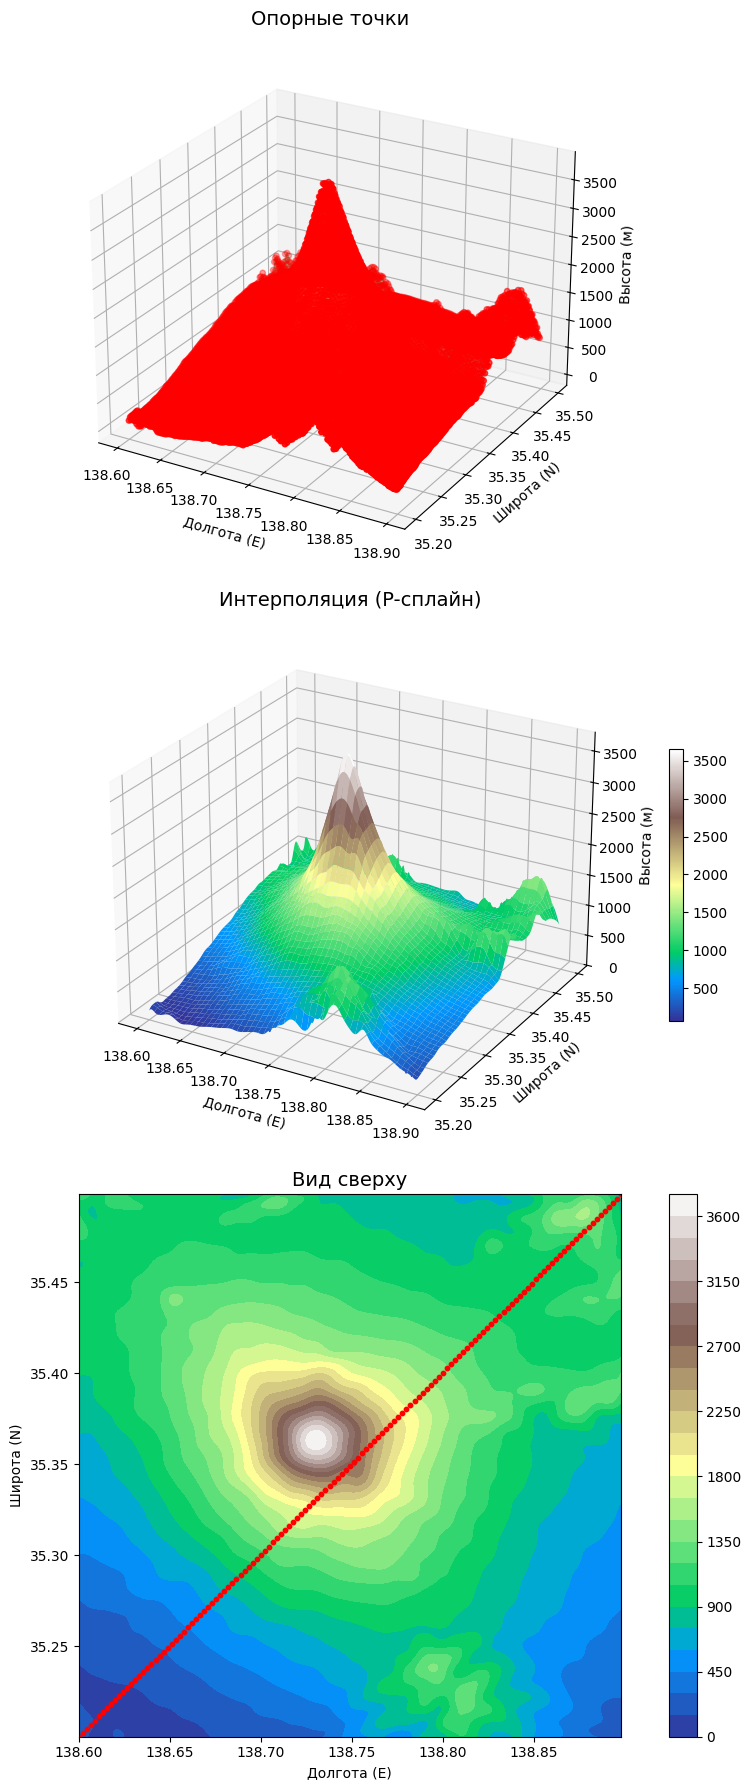

In [24]:
# ============================
# Визуализация
# ============================

fig = plt.figure(figsize=(10, 18))

# --- 1. Опорные точки ---
ax1 = fig.add_subplot(311, projection='3d')

X_display_pts, Y_display_pts = np.meshgrid(X_pts, Y_pts)
X_display_grid, Y_display_grid = np.meshgrid(X_smooth, Y_smooth)

ax1.plot_surface(X_display_pts, Y_display_pts, Z_pts,
                 cmap='terrain', alpha=0.6)
ax1.scatter(X_display_pts, Y_display_pts, Z_pts, c='red', s=15)

ax1.set_title('Опорные точки', fontsize=14)
ax1.set_xlabel(x_label)
ax1.set_ylabel(y_label)
ax1.set_zlabel('Высота (м)')
ax1.view_init(25, -60)

# --- 2. Интерполяция P-сплайном ---
ax2 = fig.add_subplot(312, projection='3d')
surf = ax2.plot_surface(X_display_grid, Y_display_grid, Z_smooth,
                        cmap='terrain', linewidth=0)

ax2.set_title('Интерполяция (P-сплайн)', fontsize=14)
ax2.set_xlabel(x_label)
ax2.set_ylabel(y_label)
ax2.set_zlabel('Высота (м)')
ax2.view_init(25, -60)

fig.colorbar(surf, ax=ax2, shrink=0.5)

# --- 3. Вид сверху ---
ax3 = fig.add_subplot(313)
contour = ax3.contourf(X_display_grid, Y_display_grid, Z_smooth,
                       levels=30, cmap='terrain')
ax3.scatter(X_pts, Y_pts, c='red', s=10)

ax3.set_title('Вид сверху', fontsize=14)
ax3.set_xlabel(x_label)
ax3.set_ylabel(y_label)
ax3.set_aspect('equal')

fig.colorbar(contour, ax=ax3)

plt.tight_layout()
plt.show()


ОЦЕНКА ОШИБКИ...
MAE  = 9.94 м
RMSE = 17.63 м
MAX  = 314.02 м


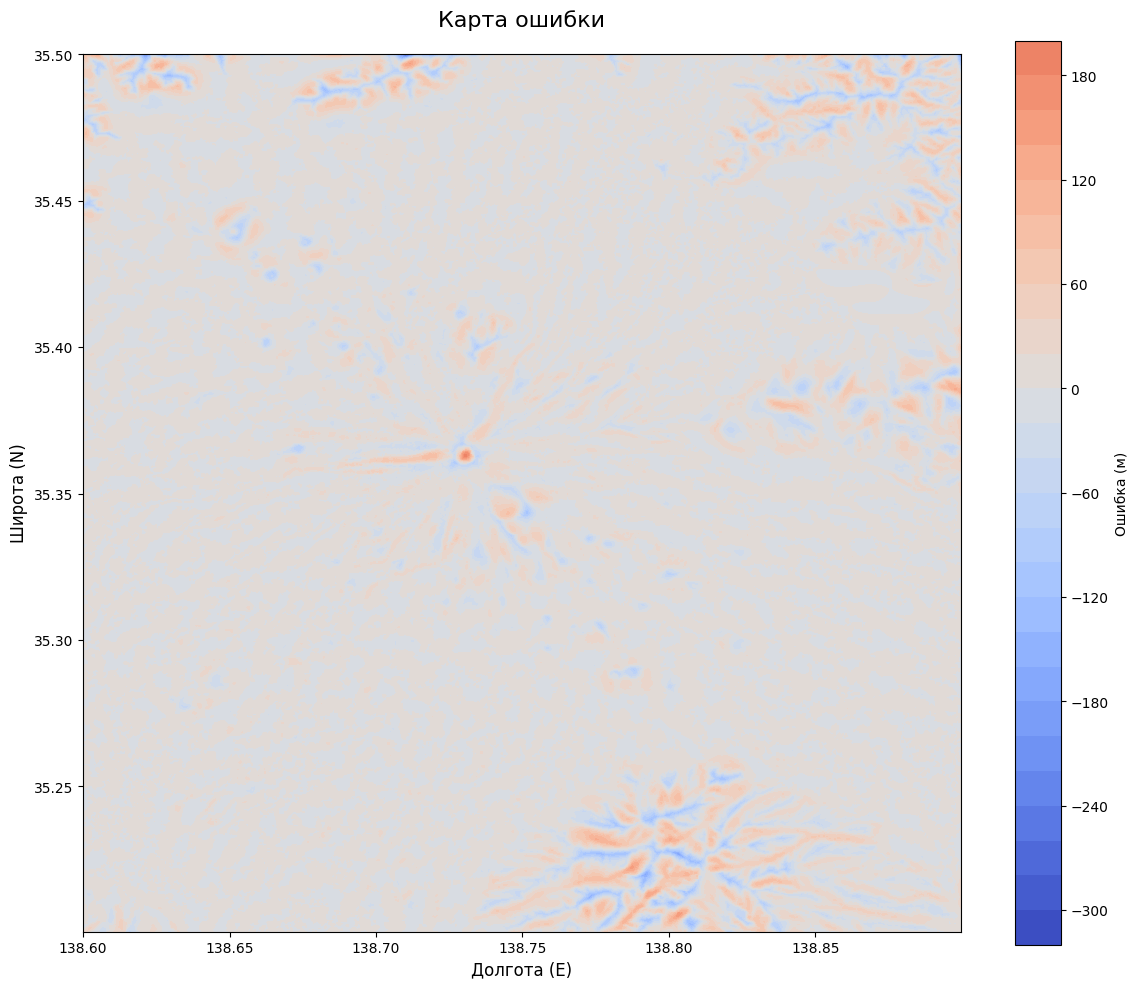

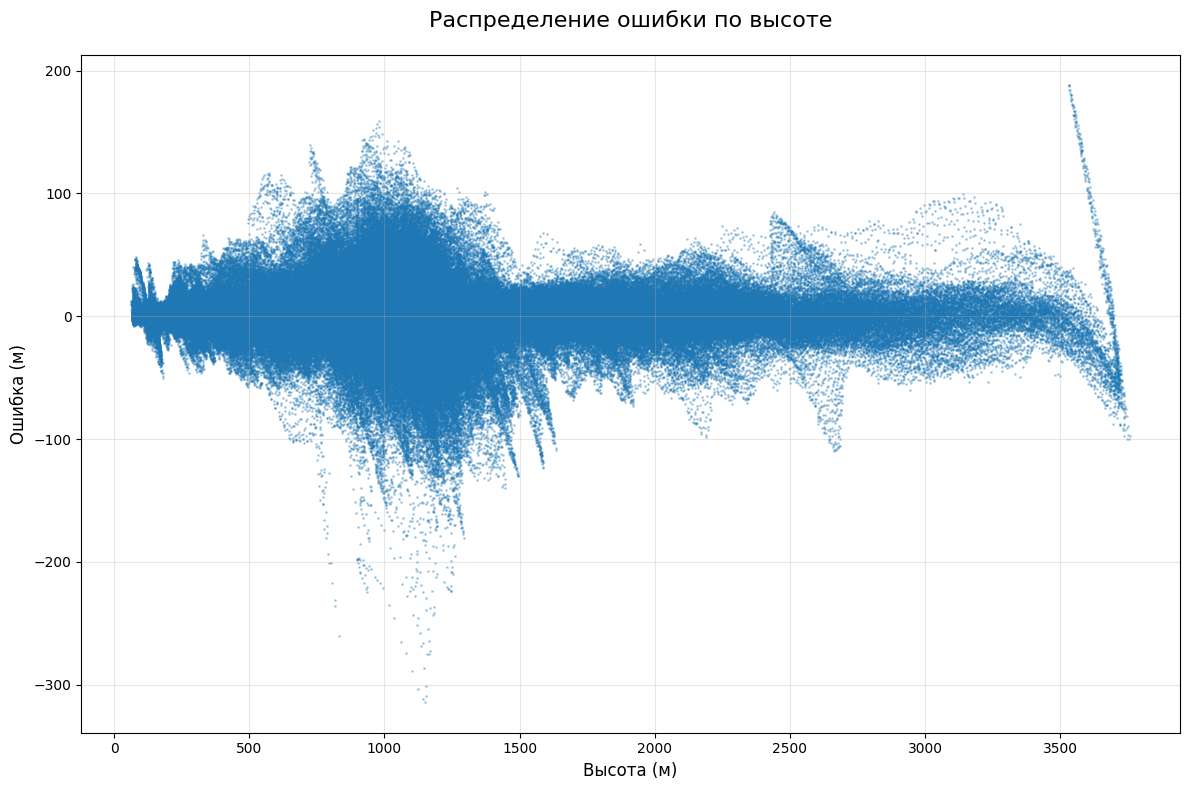

In [25]:
# ============================
# Оценка ошибки
# ============================

print("\nОЦЕНКА ОШИБКИ...")

Z_interp_on_raw = pspline_2d_eval(A, kx, ky, X_coords, Y_coords, degree=3)

error = Z_interp_on_raw - Z_raw

mae = np.nanmean(np.abs(error))
rmse = np.sqrt(np.nanmean(error**2))
max_err = np.nanmax(np.abs(error))

print(f"MAE  = {mae:.2f} м")
print(f"RMSE = {rmse:.2f} м")
print(f"MAX  = {max_err:.2f} м")


# ============================
# Карта ошибки
# ============================

Xg, Yg = np.meshgrid(X_coords, Y_coords)
v = np.nanmax(np.abs(error))

plt.figure(figsize=(12, 10))
c = plt.contourf(Xg, Yg, error, levels=30, cmap='coolwarm', vmin=-v, vmax=v)

plt.title('Карта ошибки', fontsize=16, pad=20)
plt.xlabel(x_label, fontsize=12)
plt.ylabel(y_label, fontsize=12)
plt.gca().set_aspect('equal')
plt.colorbar(c, label='Ошибка (м)')

plt.tight_layout()
plt.show()


# ============================
# Распределение ошибки по высоте
# ============================

plt.figure(figsize=(12, 8))
plt.scatter(Z_raw.flatten(), error.flatten(), s=1, alpha=0.3)

plt.title('Распределение ошибки по высоте', fontsize=16, pad=20)
plt.xlabel('Высота (м)', fontsize=12)
plt.ylabel('Ошибка (м)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()